<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Water supply temperature
</div>

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
aggregated = pd.read_csv("aggregated_data.csv")

# Filter for laboratory washing machine data
laboratory = aggregated[
    aggregated["environment"].str.contains("laboratory", na=False) &
    aggregated["type"].str.contains("wm", na=False)
]

def report_correlation(df: pd.DataFrame) -> dict:
    correlations = {
        'Pearson': df["outside_temp"].corr(df["water_temp"], method='pearson'),
        'Spearman': df["outside_temp"].corr(df["water_temp"], method='spearman'),
        'Kendall': df["outside_temp"].corr(df["water_temp"], method='kendall'),
    }
    for name, value in correlations.items():
        print(f"{name} Correlation: {value:.3f}")
    return correlations

def draw_linear_relationship(df: pd.DataFrame, ambient_setting: str, min_max: str = "min"):
    X = df["outside_temp"].values.reshape(-1, 1)
    y = df["water_temp"].values

    # Fit linear regression
    model = LinearRegression().fit(X, y)

    # Create trendline
    x_smooth = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_smooth = model.predict(x_smooth)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(df["outside_temp"], df["water_temp"], color='#019ac2', label="Data Points")
    plt.plot(x_smooth, y_smooth, color='#f58220', linestyle="--", label="Linear Trend")
    
    plt.xlabel("Outside Temperature (°C)", fontsize=16)
    plt.ylabel("Water Temperature (°C)", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True)
    plt.legend(fontsize=14)

    # pdf_filename = f"linear_relationship_ambient_{ambient_setting}_{min_max}.pdf"
    # plt.savefig(pdf_filename, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()


<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Plot correlation
</div>


Setting: cold


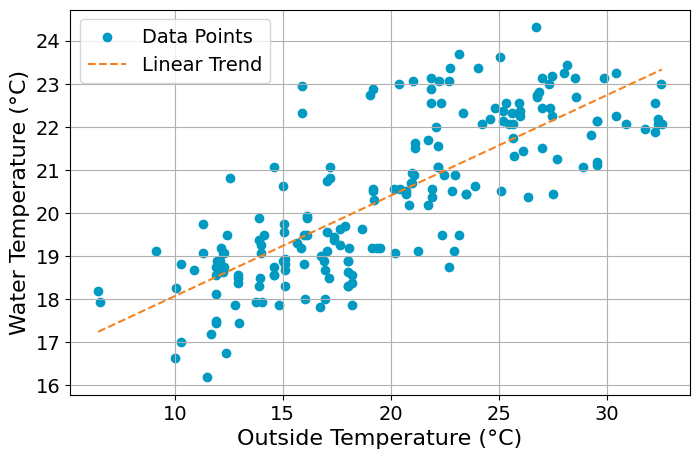

Pearson Correlation: 0.784
Spearman Correlation: 0.785
Kendall Correlation: 0.575

Setting: warm


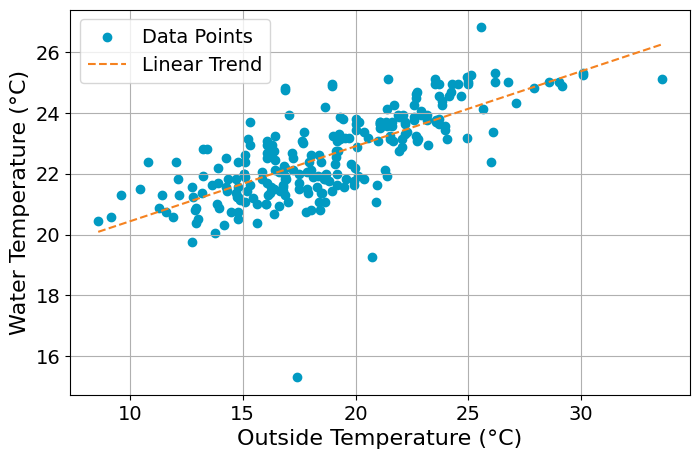

Pearson Correlation: 0.725
Spearman Correlation: 0.758
Kendall Correlation: 0.568

Setting: hot


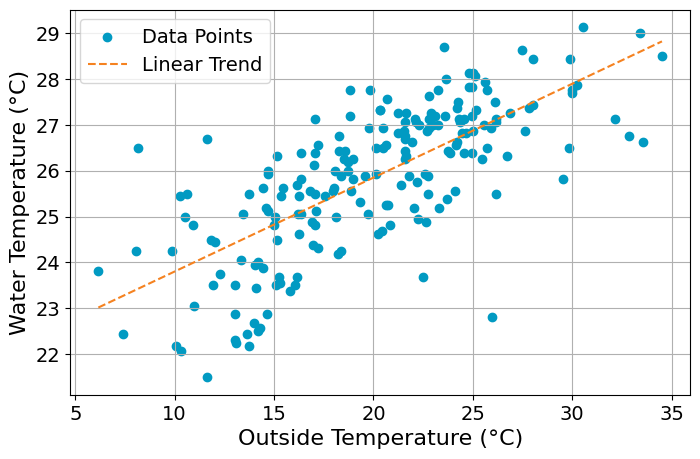

Pearson Correlation: 0.719
Spearman Correlation: 0.744
Kendall Correlation: 0.554


In [9]:
import pandas as pd

# 1. Load the data
ambient_df = pd.read_csv('weather_data.csv')

# 2. Convert timestamps
#    errors='coerce' turns unparseable data (like empty strings) into NaT (Not a Time)
laboratory['timestamp'] = pd.to_datetime(laboratory['timestamp'], format='mixed', utc=True, errors='coerce')
ambient_df['timestamp'] = pd.to_datetime(ambient_df['timestamp'], format='mixed', utc=True, errors='coerce')

# --- THE FIX: Drop rows where timestamp became NaT ---
laboratory = laboratory.dropna(subset=['timestamp'])
ambient_df = ambient_df.dropna(subset=['timestamp'])
# ----------------------------------------------------

# 3. Sort by timestamp (Required for merge_asof)
laboratory = laboratory.sort_values('timestamp')
ambient_df = ambient_df.sort_values('timestamp')

# 4. Merge using 'merge_asof'
laboratory_synced = pd.merge_asof(
    laboratory, 
    ambient_df[['timestamp', 'temperature']], 
    on='timestamp', 
    direction='nearest',
    tolerance=pd.Timedelta("1s") # Adjust tolerance if needed (e.g. "1min")
)

# Loop through AC settings
for setting in ["cold", "warm", "hot"]:
    temps = {"outside_temp": [], "water_temp": []}

    for _, row in laboratory_synced.iterrows():
        
        # Get temperature (handle missing values)
        current_temp = row.get("temperature", 0)
        
        # Check for NaN (in case merge found no match within tolerance)
        if pd.isna(current_temp):
            continue
            
        if row.get("ac_set") != setting or current_temp <= 0:
            continue

        try:
            temp_df = pd.read_csv(row['file_path'])
            water_in = temp_df["water_temperature_in"].iloc[1:]

            if water_in.min() > 0:
                water_temp = water_in.max() if setting == "cold" else water_in.min()
                temps["water_temp"].append(water_temp)
                temps["outside_temp"].append(current_temp)

        except Exception as e:
            print(f"Error processing {row.get('file_path')}: {e}")
            continue

    if len(temps["water_temp"]) > 0:
        df_temps = pd.DataFrame(temps)
        print(f"\nSetting: {setting}")
        draw_linear_relationship(df_temps, setting, "min" if setting == "cold" else "max")
        report_correlation(df_temps)
    else:
        print(f"No valid data for setting: {setting}")

<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Water drain temperature
</div>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
aggregated = pd.read_csv("aggregated_data.csv")

# Filter for laboratory washing machine data
laboratory = aggregated[
    aggregated["environment"].str.contains("laboratory", na=False) &
    aggregated["type"].str.contains("wm", na=False)
]

max_out_temp = []

temps = {'hot': {}, "cold": {}, "warm":{}}
cont_90 = 0
for idx, row in laboratory.iterrows():
    try:        
        temp_df_path = row["file_path"]
        
        temp_df_wm = pd.read_csv(temp_df_path)
        
        if row["program_heat"] == "40-60":
            continue
        
        # if max(temp_df_wm["water_temperature_out"]) > 0 and max(temp_df_wm["water_temperature_out"]) < 50:
        if max(temp_df_wm["water_temperature_out"]) > 0:
            if int(row["program_heat"]) not in temps[row["ac_set"]]:
                temps[row["ac_set"]][int(row["program_heat"])] = []
            temps[row["ac_set"]][int(row["program_heat"])].append(max(temp_df_wm["water_temperature_out"]))
            
            if row["program_heat"] == 90:
                cont_90 += 1

    except Exception as e:
        print(e)
        print(temp_df_path)

<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Plot water drain temperature
</div>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
aggregated = pd.read_csv("aggregated_data.csv")

# Filter for laboratory washing machine data
laboratory = aggregated[
    aggregated["environment"].str.contains("laboratory", na=False) &
    aggregated["type"].str.contains("wm", na=False)
]

max_out_temp = []

temps = {'hot': {}, "cold": {}, "warm": {}}
cont_90 = 0

for idx, row in laboratory.iterrows():
    try:
        temp_df_path = row["file_path"]
        temp_df_wm = pd.read_csv(temp_df_path)

        # Skip mixed temp program
        if row["program_heat"] == "40-60":
            continue

        # Only consider cycles with positive water outlet temp
        if temp_df_wm["water_temperature_out"].max() > 0:
            if int(row["program_heat"]) not in temps[row["ac_set"]]:
                temps[row["ac_set"]][int(row["program_heat"])] = []

            temps[row["ac_set"]][int(row["program_heat"])].append(
                temp_df_wm["water_temperature_out"].max()
            )

            if row["program_heat"] == 90:
                cont_90 += 1

    except Exception as e:
        print(e)
        print(temp_df_path)

# ------------------------------------------------------------------
# NEW PART: household max temp_out per cycle (file), for Hs box
# ------------------------------------------------------------------
household = aggregated[
    aggregated["environment"].str.contains("household", na=False)
    # If you also want only washing machines, uncomment next line:
    # & aggregated["type"].str.contains("wm", na=False)
]

household_max_temp_out = []

for idx, row in household.iterrows():
    try:
        temp_df_path = row["file_path"]
        temp_df_wm = pd.read_csv(temp_df_path)

        # Clean/validate temp_out
        if "temp_out" not in temp_df_wm.columns:
            continue

        t_out = temp_df_wm["temp_out"].replace(-1, np.nan).dropna()
        if len(t_out) == 0:
            continue

        max_t_out = t_out.max()

        # Keep only positive values (similar to lab condition)
        if max_t_out > 0:
            household_max_temp_out.append(max_t_out)

    except Exception as e:
        print(e)
        print(temp_df_path)

# ------------------------------------------------------------------
# Build lab data/labels as before
# ------------------------------------------------------------------
sorted_keys = sorted({int(temp) for cat in temps for temp in temps[cat]})
print(sorted_keys)

categories = ["cold", "warm", "hot"]  # Define order of categories

data = []
labels = []

for temp in sorted_keys:
    for category in categories:
        if temp in temps[category]:
            values = temps[category][temp]
            if values:  # Avoid empty lists
                data.append(values)
                labels.append(f"{category.capitalize()} - {temp}°C")

# Add household series as an extra box called Hs
if household_max_temp_out:
    data.append(household_max_temp_out)
    labels.append("Household")  # Household max temp_out per cycle


# ------------------------------------------------------------------
# Plot boxplot
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6))
bp = plt.boxplot(
    data,
    patch_artist=True,
    boxprops=dict(facecolor="#019ac2"),
    medianprops=dict(color="#f58220", linewidth=2),
)

# Color only the Household box in #BA2014
# (Household is the last entry appended to `data` and `labels`)
bp["boxes"][-1].set_facecolor("#BA2014")

plt.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.7)

# Formatting
plt.xticks(range(1, len(labels) + 1), labels, rotation=45)
plt.ylabel("Water Outlet Temperature (°C)", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# plt.savefig(
#     "water_outlet_temperature_with_household.pdf",
#     format="pdf",
#     bbox_inches="tight"
# )

plt.show()


<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Washing machine drum door temperature
</div>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
aggregated = pd.read_csv("aggregated_data.csv")

# Filter for laboratory washing machine data
laboratory = aggregated[
    aggregated["environment"].str.contains("laboratory", na=False) &
    aggregated["type"].str.contains("wm", na=False)
]

temps = {'hot': {}, "cold": {}, "warm":{}}

for idx, row in laboratory.iterrows():
    try:
        # Read the CSV file for each row
        temp_df_path = row["file_path"]
        temp_df_wm = pd.read_csv(temp_df_path)
        
        # Does not include eco 40-60 program
        if row["program_heat"] == "40-60":
            continue
        # Prepare the temps dictionary for each ac_set and program_heat
        if int(row["program_heat"]) not in temps[row["ac_set"]]:
            temps[row["ac_set"]][int(row["program_heat"])] = []
            
        if min(temp_df_wm["drum_door_temp"]) == -1:
            continue
        
        if temp_df_path == "./laboratory/washing_machine/becken_BWM5379IX/cotton/wm_becken_BWM5379IX_cold_cotton_0_7.csv":
            continue
        
        if len(temp_df_wm['drum_door_temp'].dropna()) == 0:
            continue
    
        temps[row["ac_set"]][int(row["program_heat"])].append(temp_df_wm["drum_door_temp"].dropna().max())
        
    except Exception as e:
        print(e)
        print(temp_df_path)

<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Plot drum door temperature
</div>

In [ ]:
# Prepare data for boxplot sorted by temperature first
sorted_keys = sorted({int(temp) for cat in temps for temp in temps[cat]})

# categories = ["hot", "warm", "cold"]  # Define order of categories
categories = ["cold", "warm", "hot"]  # Define order of categories

data = []
labels = []
for temp in sorted_keys:
    for category in categories:
        if temp in temps[category]:
            values = temps[category][temp]
            if values:  # Avoid empty lists
                data.append(values)
                labels.append(f"{category.capitalize()} - {temp}°C")

# Plot boxplot
plt.figure(figsize=(12, 6))
plt.boxplot(data, patch_artist=True, boxprops=dict(facecolor="#019ac2"),medianprops=dict(color="#f58220", linewidth=2))
plt.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.7)
# Formatting
plt.xticks(range(1, len(labels) + 1), labels, rotation=45)
plt.ylabel("Drum Door Temperature (°C)", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)

# plt.savefig("drum_door_temperature.pdf", format="pdf", bbox_inches="tight")
# Show plot
plt.show()

<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Washing machine drum temperature
</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Load dataset
aggregated = pd.read_csv("aggregated_data.csv")

# Filter for laboratory washing machine data ONLY
# Use equality if your 'type' column uses 'wm'/'dr' abbreviations; avoid 'contains' pitfalls
laboratory = aggregated[
    aggregated["environment"].str.lower().eq("laboratory") &
    aggregated["type"].str.lower().eq("wm")
]

# temps[ac_set][program_heat_int] -> list of max drum temps
temps = {"hot": defaultdict(list), "warm": defaultdict(list), "cold": defaultdict(list)}

for _, row in laboratory.iterrows():
    try:
        temp_df_path = row["file_path"]
        temp_df_wm = pd.read_csv(temp_df_path)

        # Skip eco 40-60 program
        if str(row["program_heat"]).strip() == "40-60":
            continue

        # Normalize AC set
        ac = str(row.get("ac_set", "")).strip().lower()
        if ac not in temps:
            # If unexpected label appears, map or skip
            continue

        # Normalize program_heat to an int (e.g., "30" -> 30, "30°C" -> 30)
        ph_raw = str(row.get("program_heat", "")).strip()
        ph_raw = ph_raw.replace("°C", "").replace(" ", "")
        try:
            ph = int(ph_raw)
        except ValueError:
            # Non-numeric program heat (already skipping 40-60, but be safe)
            continue

        # Quality checks on drum_temperature
        if "drum_temperature" not in temp_df_wm.columns:
            continue
        drum = temp_df_wm["drum_temperature"].dropna()
        if drum.empty:
            continue
        if drum.min() == -1:  # your sentinel for missing sensor
            continue

        # Exclude this specific known-bad sample
        if temp_df_path == "./laboratory/washing_machine/becken_BWM5379IX/cotton/wm_becken_BWM5379IX_cold_cotton_0_7.csv":
            continue

        # Append max drum temp for this cycle
        temps[ac][ph].append(drum.max())

    except Exception as e:
        print(f"Error on {temp_df_path}: {e}")

# ---- Plotting ----

# Sorted unique program heats across all categories (now they are ints)
sorted_heats = sorted({ph for ac in temps for ph in temps[ac].keys()})
categories = ["cold", "warm", "hot"]  # desired order

data, labels = [], []
for ph in sorted_heats:
    for ac in categories:
        vals = temps[ac].get(ph, [])
        if vals:
            data.append(vals)
            labels.append(f"{ac.capitalize()} - {ph}°C")

if not data:
    print("No data to plot. Check filters and key normalization.")
else:
    plt.figure(figsize=(12, 6))
    plt.boxplot(
        data,
        patch_artist=True,
        boxprops=dict(facecolor="#019ac2"),
        medianprops=dict(color="#f58220", linewidth=2)
    )
    plt.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.7)
    plt.xticks(range(1, len(labels) + 1), labels, rotation=45, ha="right", fontsize=12)
    plt.ylabel("Drum Temperature (°C)", fontsize=14)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    # plt.savefig("drum_temperature.pdf", format="pdf", bbox_inches="tight")
    plt.show()

<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Ambient temperature
</div>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
aggregated = pd.read_csv("aggregated_data.csv")

# Filter for laboratory washing machine data
laboratory = aggregated[
    aggregated["environment"].str.contains("laboratory", na=False)
]

# Prepare the temps dictionary for each ac_set and program_heat
temps = {'hot': {"ambient_temperature_1":[],"ambient_temperature_2":[]}, "cold": {"ambient_temperature_1":[],"ambient_temperature_2":[]}, "warm":{"ambient_temperature_1":[],"ambient_temperature_2":[]}}

for idx, row in laboratory.iterrows():
    try:
        # Read the CSV file for each row
        temp_df_path = row["file_path"]
        temp_df = pd.read_csv(temp_df_path)
        
        
        if temp_df["ambient_temperature_1"].values[0] == -1 or temp_df["ambient_temperature_2"].values[0] == -1:
            continue
        
        if len(temp_df["ambient_temperature_1"].dropna()) == 0:
            continue
        
        temps[row["ac_set"]]["ambient_temperature_1"].append(temp_df["ambient_temperature_1"].dropna().mean())
        temps[row["ac_set"]]["ambient_temperature_2"].append(temp_df["ambient_temperature_2"].dropna().mean())
        
    except Exception as e:
        print(e)
        print(temp_df_path)

<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Plot ambient temperature
</div>

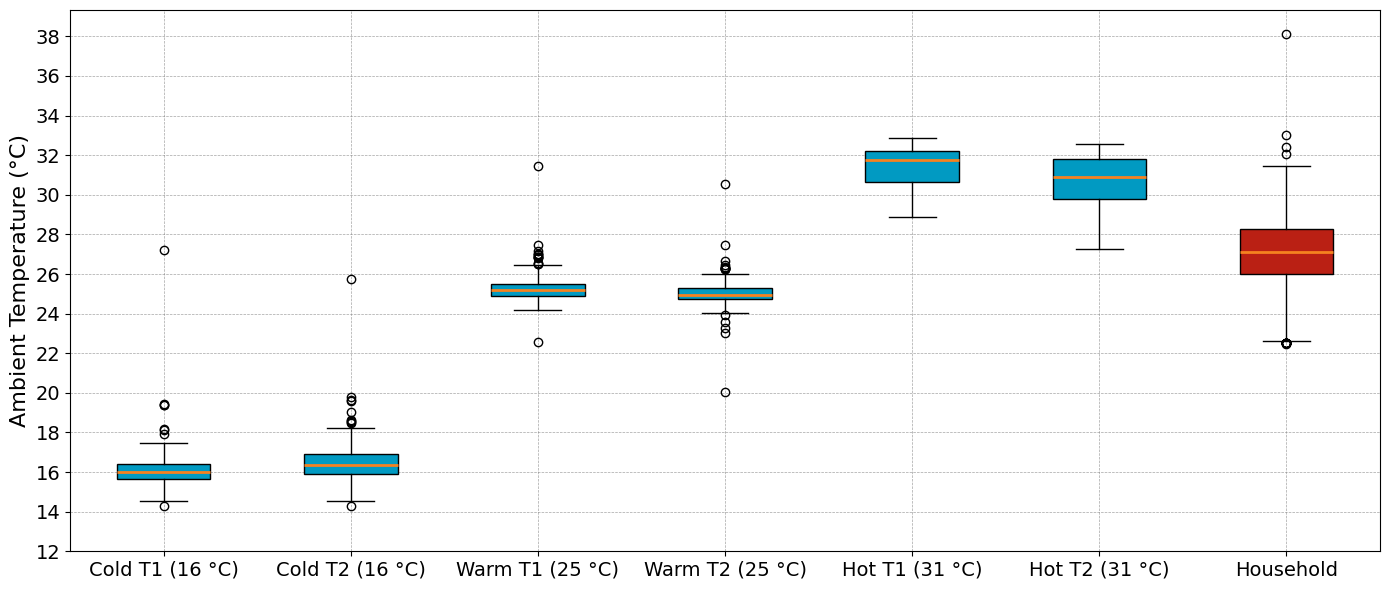

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
aggregated = pd.read_csv("aggregated_data.csv")

# Filter for laboratory washing machine data
laboratory = aggregated[
    aggregated["environment"].str.contains("laboratory", na=False)
]

# Prepare the temps dictionary for each ac_set and program_heat
temps = {
    "hot":  {"ambient_temperature_1": [], "ambient_temperature_2": []},
    "cold": {"ambient_temperature_1": [], "ambient_temperature_2": []},
    "warm": {"ambient_temperature_1": [], "ambient_temperature_2": []},
}

for idx, row in laboratory.iterrows():
    try:
        temp_df_path = row["file_path"]
        temp_df = pd.read_csv(temp_df_path)

        # Skip invalid or missing data
        if (
            temp_df["ambient_temperature_1"].values[0] == -1
            or temp_df["ambient_temperature_2"].values[0] == -1
        ):
            continue

        if len(temp_df["ambient_temperature_1"].dropna()) == 0:
            continue

        temps[row["ac_set"]]["ambient_temperature_1"].append(
            temp_df["ambient_temperature_1"].dropna().mean()
        )
        temps[row["ac_set"]]["ambient_temperature_2"].append(
            temp_df["ambient_temperature_2"].dropna().mean()
        )

    except Exception as e:
        print(e)
        print(temp_df_path)

# ------------------------------------------------------------------
# NEW PART: collect household max(ambient_temperature_1) per file
# ------------------------------------------------------------------
household = aggregated[
    aggregated["environment"].str.contains("household", na=False)
]

household_max_t1 = []

for idx, row in household.iterrows():
    try:
        temp_df_path = row["file_path"]
        temp_df = pd.read_csv(temp_df_path)

        # Clean data: treat -1 as invalid
        t1_series = temp_df["ambient_temperature_1"].replace(-1, np.nan).dropna()
        if len(t1_series) == 0:
            continue

        # Store the maximum temperature in this file
        household_max_t1.append(t1_series.values[0])

    except Exception as e:
        print(e)
        print(temp_df_path)

# ------------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------------
categories = ["cold", "warm", "hot"]
temp_keys = ["ambient_temperature_1", "ambient_temperature_2"]

label_map = {
    "cold": {
        "ambient_temperature_1": "Cold T1 (16 °C)",
        "ambient_temperature_2": "Cold T2 (16 °C)",
    },
    "warm": {
        "ambient_temperature_1": "Warm T1 (25 °C)",
        "ambient_temperature_2": "Warm T2 (25 °C)",
    },
    "hot": {
        "ambient_temperature_1": "Hot T1 (31 °C)",
        "ambient_temperature_2": "Hot T2 (31 °C)",
    },
}

data = []
labels = []

# Existing lab series
for category in categories:
    for temp_key in temp_keys:
        values = temps[category].get(temp_key, [])
        if values:
            data.append(values)
            labels.append(label_map[category][temp_key])

# Add household boxplot as "Hs"
if household_max_t1:
    data.append(household_max_t1)
    labels.append("Household")  # <- x-axis label for household max T1

plt.figure(figsize=(14, 6))
bp = plt.boxplot(
    data,
    patch_artist=True,
    boxprops=dict(facecolor="#019ac2"),
    medianprops=dict(color="#f58220", linewidth=2),
)

# All boxes start with the default color (#019ac2).
# Now set only the last one (Household) to #BA2014
bp["boxes"][-1].set_facecolor("#BA2014")

plt.yticks(range(12, 39, 2))
plt.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.7)
plt.xticks(range(1, len(labels) + 1), labels, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Ambient Temperature (°C)", fontsize=16)

plt.tight_layout()
# plt.savefig("ambient_temperatures_lab_household.pdf", format="pdf", bbox_inches="tight")
plt.show()



<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Pressure
</div>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

aggregated = pd.read_csv("aggregated_data.csv")
laboratory_wm = aggregated[aggregated["environment"].str.contains("laboratory", na=False) & aggregated["type"].str.contains("wm", na=False)]
household_wm = aggregated[aggregated["environment"].str.contains("household", na=False) & aggregated["type"].str.contains("wm", na=False)]

In [ ]:
import numpy as np

lab_water_pressure = []

for idx, row in laboratory_wm.iterrows():

    df = pd.read_csv(row['file_path'])

    if "pressure" not in df.columns: # Skip cycles that do not have pressure sensor yet
        continue
    
    lab_water_pressure.append(df["pressure"].mean())

In [ ]:
def get_house_code(model):
    if "WDYN654D" in model:
        return "H1"
    elif "WW80T554DTW" in model:
        return "H2"
    elif "EWF1272EOW" in model:
        return "H3"
    elif "FMG823B" in model:
        return "H4"
    elif "L6FBG141" in model:
        return "H5"
    elif "WF80F5E0W2W" in model:
        return "H6"
    elif "3TS866EE" in model:
        return "H7"
    else:
        return None  # Unknown or unmatched

In [ ]:
wm_map = {"H1": [], "H2": [], "H3": [], "H4": [], "H5": [], "H6": [], "H7": [], "L" : lab_water_pressure}

for idx, row in household_wm.iterrows():    
    if row["model"] == "DHS7412PA0": # skipping, has no pressure
        continue
    df = pd.read_csv(row['file_path'])
    wm_map[get_house_code(row["model"])].append(df["water_pressure"].mean())

In [ ]:
import matplotlib.pyplot as plt

# Assume wm_map and labels already defined
labels = ["H1", "H2", "H3", "H4", "H5", "H6", "H7", "L"]
data = [wm_map[label] for label in labels]

plt.figure(figsize=(12, 6))
bp = plt.boxplot(
    data,
    patch_artist=True,
    boxprops=dict(facecolor="#019ac2"),  # default for all (L will stay this color)
    medianprops=dict(color="#f58220", linewidth=2)
)

# Recolor all H* boxes to #BA2014, leave L as #019ac2
for box, label in zip(bp["boxes"], labels):
    if label.startswith("H"):
        box.set_facecolor("#BA2014")

plt.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.7)

# Axis formatting
plt.xticks(range(1, len(labels) + 1), labels, fontsize=14)
plt.yticks(range(100, 750 + 1, 50), fontsize=14)
plt.ylabel("Pressure (kPa)", fontsize=16)

plt.savefig("wm_pressure_boxplot.pdf", format="pdf", bbox_inches="tight")
plt.show()


<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Dryer lint trap temperature
</div>

<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Dryer BDM2741
</div>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

aggregated = pd.read_csv("aggregated_data.csv")
laboratory_dr = aggregated[aggregated["environment"].str.contains("laboratory", na=False) & aggregated["type"].str.contains("dm", na=False)]

max_out_temp = []
temps = {'hot': {}, "cold": {}, "warm":{}}
max_inside_temp = []

for idx, row in laboratory_dr.iterrows():
    try:        
        temp_df_path = row["file_path"]
        temp_df_dr = pd.read_csv(temp_df_path)
        
        if "2741" in temp_df_path:                
            if row["program_name"] not in temps[row["ac_set"]]:
                temps[row["ac_set"]][row["program_name"]] = {"T1": [], "T2": []}
            
            if min(temp_df_dr["inside_temperature"]) == -1 or pd.isna(min(temp_df_dr["inside_temperature"])):
                continue
            
            if max(temp_df_dr["inside_temperature"]) > 100:
                print("Temperature exceeds 100")
                print(temp_df_path)
                print(max(temp_df_dr["inside_temperature"]) )    
            
            temps[row["ac_set"]][row["program_name"]]["T1"].append(max(temp_df_dr["inside_temperature"]))
            temps[row["ac_set"]][row["program_name"]]["T2"].append(max(temp_df_dr["inside_temperature_2"]))
        
            if max(temp_df_dr["inside_temperature_2"]) > 100:
                print(f'Temp exceeds 100 at {temp_df_path}')
                print(max(temp_df_dr["inside_temperature_2"]))
        

    except Exception as e:
        print(e)
        continue

In [ ]:
# Prepare data for boxplot
categories = ["cold", "warm", "hot"]  # Define order of categories

data = []
labels = []
for category in categories:
    sorted_programs = sorted(temps[category].keys())  # Sort programs alphabetically
    for program in sorted_programs:
        for temp_type in ["T1", "T2"]:  # Ensure T1 comes before T2
            if temp_type in temps[category][program]:
                values = temps[category][program][temp_type]
                if values:  # Avoid empty lists
                    data.append(values)
                    labels.append(f"{category.capitalize()} - {program.capitalize()} ({temp_type})")

# Plot boxplot
plt.figure(figsize=(14, 6))
plt.boxplot(data, patch_artist=True, boxprops=dict(facecolor="#019ac2"), medianprops=dict(color="#f58220", linewidth=2))
plt.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.7)

# Formatting
plt.xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right',fontsize=14)
plt.yticks(range(32, 65, 2),fontsize=14)  # More frequent Y-axis ticks every 2 degrees
plt.ylabel("Lint Trap Chamber Temperature (°C)",fontsize=16)


# plt.savefig("2741_lint_trap_t1_t2.pdf", format="pdf", bbox_inches="tight")
# Show plot
plt.show()


<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Dryer BDM8331
</div>

In [ ]:
import pandas as pd
aggregated = pd.read_csv("aggregated_data.csv")
laboratory_dr = aggregated[aggregated["environment"].str.contains("laboratory", na=False) & aggregated["type"].str.contains("dm", na=False)]

import statistics

import matplotlib.pyplot as plt
max_out_temp = []

temps = {'hot': {}, "cold": {}, "warm":{}}

cont_90 = 0

cnt = 0

max_inside_temp = []

for idx, row in laboratory_dr.iterrows():
    try:
        temp_df_path = row["file_path"]
        temp_df_dr = pd.read_csv(temp_df_path)
        
        if "8331" in temp_df_path:
                
            if row["program_name"] not in temps[row["ac_set"]]:
                temps[row["ac_set"]][row["program_name"]] = {"T1": [], "T2": []}
            
            if min(temp_df_dr["inside_temperature"]) == -1 or pd.isna(min(temp_df_dr["inside_temperature"])):
                continue
            
            if max(temp_df_dr["inside_temperature"]) > 80: # anomaly check
                print(f'Temp exceeds 80 at {temp_df_path}. Temp detected {max(temp_df_dr["inside_temperature"])}')
                continue
            
            if max(temp_df_dr["inside_temperature_2"]) > 80: # anomaly check
                print(f'Temp exceeds 80 at {temp_df_path}. Temp detected {max(temp_df_dr["inside_temperature_2"])}')
                continue
            
            temps[row["ac_set"]][row["program_name"]]["T1"].append(max(temp_df_dr["inside_temperature"]))
            temps[row["ac_set"]][row["program_name"]]["T2"].append(max(temp_df_dr["inside_temperature_2"]))

    except Exception as e:
        print(e)
        continue

In [ ]:
# Prepare data for boxplot
categories = ["cold", "warm", "hot"]  # Define order of categories

data = []
labels = []
for category in categories:
    sorted_programs = sorted(temps[category].keys())  # Sort programs alphabetically
    for program in sorted_programs:
        for temp_type in ["T1", "T2"]:  # Ensure T1 comes before T2
            if temp_type in temps[category][program]:
                values = temps[category][program][temp_type]
                if values:  # Avoid empty lists
                    data.append(values)
                    labels.append(f"{category.capitalize()} - {program.capitalize()} ({temp_type})")

# Plot boxplot
plt.figure(figsize=(14, 6))
plt.boxplot(data, patch_artist=True, boxprops=dict(facecolor="#019ac2"), medianprops=dict(color="#f58220", linewidth=2))
plt.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.7)

# Formatting
plt.xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right',fontsize=14)
plt.yticks(range(32, 65, 2),fontsize=14)  # More frequent Y-axis ticks every 2 degrees
plt.ylabel("Lint Trap Chamber Temperature (°C)",fontsize=16)


# plt.savefig("8331_lint_trap_t1_t2.pdf", format="pdf", bbox_inches="tight")
# Show plot
plt.show()


<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Initial Lint Trap Temperature
</div>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
aggregated = pd.read_csv("aggregated_data.csv")
laboratory_dr = aggregated[aggregated["environment"].str.contains("laboratory", na=False) & aggregated["type"].str.contains("dm", na=False)]

max_out_temp = []
temps = {'hot': {}, "cold": {}, "warm":{}}
max_inside_temp = []

for idx, row in laboratory_dr.iterrows():
    try:
        temp_df_path = row["file_path"]
        temp_df_dr = pd.read_csv(temp_df_path)
                
        if "T1" not in temps[row["ac_set"]]:
            temps[row["ac_set"]] = {"T1": [], "T2": []}
        
        if min(temp_df_dr["inside_temperature"]) == -1 or pd.isna(min(temp_df_dr["inside_temperature"])):
            continue
        
        if "syn" in temp_df_path and row["target_load"] == 1:
            continue
        
        if "beds" in temp_df_path and row["target_load"] == 7:
            continue
        
        temps[row["ac_set"]]["T1"].append(min(temp_df_dr["inside_temperature"]))
        temps[row["ac_set"]]["T2"].append(min(temp_df_dr["inside_temperature"]))
        
    except Exception as e:
        print(e)
        continue

In [ ]:
# 1. Prepare the data and labels
categories = ["cold", "warm", "hot"]
box_data = []
labels = []

for cat in categories:
    # T1 box
    box_data.append(temps[cat]["T1"])
    labels.append(f"{cat.capitalize()} - T1")

    # T2 box
    box_data.append(temps[cat]["T2"])
    labels.append(f"{cat.capitalize()} - T2")

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    box_data,
    labels=labels,
    patch_artist=True,  # <--- This is crucial to fill the boxes
    boxprops=dict(facecolor="#019ac2"),
    medianprops=dict(color="#f58220", linewidth=2)
)

# Set title and labels
# ax.set_title("Initial Lint Trap Temperatures (T1 and T2) Before Drying.")
ax.set_ylabel("Temperature (°C)",fontsize=16)
plt.yticks(range(14, 35, 2),fontsize=14)  # More frequent Y-axis ticks every 2 degrees
plt.xticks(fontsize=14)
ax.grid(True, which="major", axis="y", color="gray", linestyle="--", alpha=0.7)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# plt.savefig("all_init_lint_trap.pdf", format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.ticker as ticker
import pandas as pd
import matplotlib.pyplot as plt

aggregated = pd.read_csv("aggregated_data.csv")
laboratory_dr = aggregated[aggregated["environment"].str.contains("laboratory", na=False) & aggregated["type"].str.contains("dm", na=False)]


plt.figure(figsize=(16, 9))

colours = ["#ff1f5c","#04cd6c", "#019ade", "#af59ba", "#ffc61f", "#f38522", "#a1b2ba", "#a6761d"]

for idx, row in laboratory_dr.iterrows():
    try:
        
        temp_df_path = row["file_path"]
        temp_df_dr = pd.read_csv(temp_df_path)
        
        if "2741" in temp_df_path and "extra" in row["program_name"] and "hot" in row["ac_set"]:
            y_values = temp_df_dr["inside_temperature"]
            x_values = range(len(y_values))  # X-axis based on index
            
            # Find max value and index
            max_temp = y_values.max()
            max_index = y_values.idxmax()
            
            plt.plot(
                x_values, y_values, 
                label=f"{row['target_load']} kg",
                linewidth=2,
                color=colours[int(row["target_load"]) - 1],)

            # Annotate max value
            plt.annotate(
                f"{max_temp:.1f}°C", 
                (max_index, max_temp), 
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center', fontsize=16, color='red'
            )
        
    except Exception as e:
        print(e)
        continue
    
    # Add labels and title

plt.xlabel("Time (Index)", fontsize=18)
plt.ylabel("Lint trap chamber temperature (°C)", fontsize=18)

# Increase legend font size and thickness
legend = plt.legend(title="Laundry Load", title_fontsize=16, fontsize=16, frameon=True)


for line in legend.get_lines():
    line.set_linewidth(5.0)  # Adjust thickness of legend lines

ax = plt.gca()  # Get current axis
ax.tick_params(axis='y', which='both', labelsize=16)  
ax.tick_params(axis='x', which='both', labelsize=16)  

# Show grid for better readability
plt.grid(True, linestyle="--", alpha=0.7)
# plt.savefig("cotton_extra_2741_hot.pdf", format="pdf", bbox_inches="tight")

plt.show()

<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Power grid readings
</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
aggregated = pd.read_csv("aggregated_data.csv")

<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Voltage
</div>

In [ ]:
accumulator_array = []
accumulator_array_hs = []

for idx, row in aggregated.iterrows():
    if row["environment"] == "laboratory":
        temp_df = pd.read_csv(row["file_path"])
        zero_count = np.sum(temp_df.voltage.values == 0)
        if zero_count > 0:
            continue # skip files with inlavid voltage
            # print(f"Zero frequency found in {row['unique_monitoring_id']} at {row['file_path']} {zero_count}")
        else:
            accumulator_array.extend(temp_df.voltage.values)
    if row["environment"] == "household":
        temp_df = pd.read_csv(row["file_path"])
        zero_count = np.sum(temp_df.voltage.values == 0)
        if zero_count > 0:
            continue # skip files with inlavid voltage
            # print(f"Zero frequency found in {row['unique_monitoring_id']} at {row['file_path']} {zero_count}")
        else:
            accumulator_array_hs.extend(temp_df.voltage.values)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define sample size
sample_size = 10000

# Ensure both arrays are NumPy arrays
accumulator_array = np.array(accumulator_array)
accumulator_array_hs = np.array(accumulator_array_hs)

# Sample Laboratory data
if len(accumulator_array) > sample_size:
    sampled_lab = np.random.choice(accumulator_array, size=sample_size, replace=False)
else:
    sampled_lab = accumulator_array

# Sample Household data
if len(accumulator_array_hs) > sample_size:
    sampled_hs = np.random.choice(accumulator_array_hs, size=sample_size, replace=False)
else:
    sampled_hs = accumulator_array_hs

# Create DataFrames
df_lab = pd.DataFrame({'Frequency (Hz)': sampled_lab, 'Source': 'Laboratory'})
df_hs  = pd.DataFrame({'Frequency (Hz)': sampled_hs,  'Source': 'Household'})

# Combine
df_combined = pd.concat([df_lab, df_hs], ignore_index=True)

# Add a single x-category so both sources share one violin position
df_combined['Group'] = 'Laboratory vs Household'

# Plot
custom_palette = {
    'Laboratory': '#3498c3',
    'Household':  '#f68320'
}

plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df_combined,
    x='Group',               # single category on x-axis
    y='Frequency (Hz)',      # same data as before
    hue='Source',            # split by source
    split=True,              # joined half–half violin
    inner='box',
    palette=custom_palette
)

plt.xlabel("")
# If this is really frequency, you might want "Frequency (Hz)" here instead of Voltage
plt.ylabel("Voltage (V)", fontsize=17)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(fontsize=17)
plt.yticks(fontsize=14)

plt.legend(title="")
plt.tight_layout()
# plt.savefig("Voltage_house_lab_violin.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()

<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Frequency
</div>

In [ ]:
accumulator_array = []
accumulator_array_hs = []

for idx, row in aggregated.iterrows():
    if row["environment"] == "laboratory":
        temp_df = pd.read_csv(row["file_path"])
        zero_count = np.sum(temp_df.frequency.values == 0)
        if zero_count > 0:
            # print(f"Zero frequency found in {row['unique_monitoring_id']} at {row['file_path']} {zero_count}")
            continue # skip files with wrong invalid data 
        else:
            accumulator_array.extend(temp_df.frequency.values)
            
    if row["environment"] == "household":
        temp_df = pd.read_csv(row["file_path"])
        zero_count = np.sum(temp_df.frequency.values == 0)
        if zero_count > 0:
            continue # skip files with wrong invalid data 
        else:
            accumulator_array_hs.extend(temp_df.frequency.values)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build a combined DataFrame
df_combined = pd.DataFrame({
    'Frequency (Hz)': list(accumulator_array) + list(accumulator_array_hs),
    'Source': (['Laboratory'] * len(accumulator_array) +
               ['Household'] * len(accumulator_array_hs)),
    # Single x-category so both violins share the same position
    'Group': 'Laboratory vs Household'
})

# Custom colors
custom_palette = {
    'Laboratory': '#3498c3',  # Blue
    'Household':  '#f68320'   # Orange
}

plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df_combined,
    x='Group',               # single x-category
    y='Frequency (Hz)',
    hue='Source',            # split by source
    split=True,              # <-- makes half-violins
    inner='box',
    palette=custom_palette
)

# Labels & formatting
plt.xlabel("")
plt.ylabel("Frequency (Hz)", fontsize=17)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(fontsize=17)
plt.yticks(fontsize=14)

# Optional: move legend or change title
plt.legend(title="")
plt.tight_layout()
plt.show()

<div style="
    background-color:#2c3e50; 
    color:#ecf0f1; 
    font-weight:bold; 
    padding:20px 30px; 
    font-size:20px; 
    border-radius:8px; 
    text-align:center;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    letter-spacing: 0.5px;
">
    Example for "Data records"
</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from scipy.io import wavfile


aggregated = pd.read_csv("aggregated_data.csv")

record = aggregated[
    (aggregated['acc'] == 1) &
    (aggregated['type'] == 'wm') &
    (aggregated['has_audio'] == 1) &
    (aggregated['program_heat'] == '40')
].head(1)

In [ ]:
umid = record["unique_monitoring_id"].values[0]

aggregated_acc = pd.read_csv("aggregated_data_acc.csv")
record_acc = aggregated_acc[
    (aggregated_acc['unique_monitoring_id'] == umid)
]

aggregated_audio = pd.read_csv("aggregated_data_audio.csv")
record_audio = aggregated_audio[
    (aggregated_audio['unique_monitoring_id'] == umid)
]

In [ ]:
record_acc["file_path"].values[0]

In [ ]:
df_agg = pd.read_csv(record["file_path"].values[0])
df_acc = pd.read_parquet(record_acc["file_path"].values[0])

In [ ]:
df_acc.columns

In [ ]:
current = df_agg["current"].values
power = df_agg["power"].values
voltage = df_agg["voltage"].values
water_inlet = df_agg["water_inlet"].values
water_temperature_in = df_agg["water_temperature_in"].values
water_outlet = df_agg["water_outlet"].values
water_temperature_out = df_agg["water_temperature_out"].values
frequency = df_agg["frequency"].values
pressure = df_agg["pressure"].values
drum_door_temp = df_agg["drum_door_temp"].values
drum_temperature = df_agg["drum_temperature"].values
ambient_temperature_1 = df_agg["ambient_temperature_1"].values
ambient_temperature_2 = df_agg["ambient_temperature_2"].values
ambient_humidity_1 = df_agg["ambient_humidity_1"].values
ambient_humidity_2 = df_agg["ambient_humidity_2"].values

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Sampling rate
# ----------------------------
fs = 1  # Hz (change this to match your actual sampling rate)

# Convert x-axis to time in minutes
x = np.arange(len(df_agg["voltage"].values))
t_minutes = x / fs / 60  # Convert from samples to minutes

# Group signals and assign custom Y-axis labels
grouped_signals = [
    {
        "label": "Voltage (V)",
        "signals": [("Voltage (V)", df_agg["voltage"].values)]
    },
    {
        "label": "Power (W)",
        "signals": [("Power (W)", df_agg["power"].values)]
    },
    {
        "label": "W pressure (kPa)",
        "signals": [("W pressure (kPa)", df_agg["pressure"].values)]
    },
    {
        "label": "W flow (ml/s)",
        "signals": [
            ("Water inlet", df_agg["water_inlet"].values, "#019ac2"),
            ("Water outlet", df_agg["water_outlet"].values, "#f68320")
        ]
    },
    {
        "label": "W temp (°C)",
        "signals": [
            ("Water temp. inlet", df_agg["water_temperature_in"].values, "#019ac2"),
            ("Water temp. outlet", df_agg["water_temperature_out"].values, "#f68320")
        ]
    },
    {
        "label": "Wm temp. (°C)",
        "signals": [
            ("Door temp.", df_agg["drum_door_temp"].values, "#019ac2"),
            ("Drum temp.", df_agg["drum_temperature"].values, "#f68320")
        ]
    },
    {
        "label": "Amb. temp. (°C)",
        "signals": [
            ("Ambient temp. 1", df_agg["ambient_temperature_1"].values, "#019ac2"),
            ("Ambient temp. 2", df_agg["ambient_temperature_2"].values, "#f68320")
        ]
    },
    {
        "label": "Amb. hum. (%)",
        "signals": [
            ("Ambient hum. 1", df_agg["ambient_humidity_1"].values, "#019ac2"),
            ("Ambient hum. 2", df_agg["ambient_humidity_2"].values, "#f68320")
        ]
    },
]

# Create subplots
fig, axes = plt.subplots(len(grouped_signals), 1, figsize=(12, 1.75 * len(grouped_signals)), sharex=True)

for ax, group in zip(axes, grouped_signals):
    for signal in group["signals"]:
        if len(signal) == 3:
            label, data, color = signal
        else:
            label, data = signal
            color = "#019ac2"

        ax.plot(t_minutes, data, linewidth=1.5, color=color, label=label)

    ax.set_ylabel(group["label"], fontsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, which="major", axis="y", color="gray", linestyle="--", alpha=0.7)
    ax.set_xlim(t_minutes[0], t_minutes[-1])
    ax.set_autoscale_on(False)

    if len(group["signals"]) > 1:
        # Create legend and then bump legend line width
        leg = ax.legend(
            fontsize=11,
            loc="upper left",
            handlelength=3,
            handletextpad=0.8,
            # frameon=False
        )
        # Make legend lines thicker while preserving colors
        for legline in leg.get_lines():
            legline.set_linewidth(2.5)
           

# Generate ticks every 10 minutes
max_time_min = t_minutes[-1]
tick_interval = 10
tick_positions = np.arange(0, max_time_min + tick_interval, tick_interval)
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels([f"{int(t)}" for t in tick_positions], fontsize=11, ha='center')

# Common X label
axes[-1].set_xlabel("Time (min)", fontsize=13)

# Layout and save
plt.tight_layout()
# plt.savefig("final_combined_plot_minutes.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()


In [ ]:
record_audio["file_path"].values[0]

In [ ]:
audio_path = record_audio["file_path"].values[0]
fs_audio, audio_data = wavfile.read(audio_path)

In [ ]:

# ----------------------------
# Load accelerometer data
# (assumes df_acc and record_audio already exist)
# ----------------------------
fs_acc = 200  # Hz
n_acc = len(df_acc["back.x"].values)
t_acc = np.arange(n_acc) / fs_acc / 60  # time in minutes

axis_colors = {
    "x": "#019ac2",
    "y": "#f68320",
    "z": "#4ecb8c",
}

grouped_signals = [
    {
        "label": "Back acceleration (g)",
        "signals": [
            ("Back X", df_acc["back.x"].values, axis_colors["x"]),
            ("Back Y", df_acc["back.y"].values, axis_colors["y"]),
            ("Back Z", df_acc["back.z"].values, axis_colors["z"]),
        ],
        "x": t_acc
    },
    {
        "label": "Side acceleration (g)",
        "signals": [
            ("Side X", df_acc["side.x"].values, axis_colors["x"]),
            ("Side Y", df_acc["side.y"].values, axis_colors["y"]),
            ("Side Z", df_acc["side.z"].values, axis_colors["z"]),
        ],
        "x": t_acc
    },
    {
        "label": "Top acceleration (g)",
        "signals": [
            ("Top X", df_acc["top.x"].values, axis_colors["x"]),
            ("Top Y", df_acc["top.y"].values, axis_colors["y"]),
            ("Top Z", df_acc["top.z"].values, axis_colors["z"]),
        ],
        "x": t_acc
    },
]

# ----------------------------
# Load audio
# ----------------------------
audio_path = record_audio["file_path"].values[0]
fs_audio, audio_data = wavfile.read(audio_path)

if len(audio_data.shape) == 2:
    audio_data = audio_data.mean(axis=1)

n_audio = len(audio_data)
t_audio = np.arange(n_audio) / fs_audio / 60  # time in minutes

grouped_signals.append({
    "label": "Audio amplitude",
    "signals": [
        ("Audio waveform", audio_data, "#f47a00")
    ],
    "x": t_audio
})

# ----------------------------
# Common time ticks
# ----------------------------
total_duration_min = max(t_acc[-1], t_audio[-1])
tick_step_min = 10
tick_positions = np.arange(0, total_duration_min + tick_step_min, tick_step_min)
tick_labels = [f"{int(t)}" for t in tick_positions]

# ----------------------------
# Plotting
# ----------------------------
fig, axes = plt.subplots(
    len(grouped_signals), 1,
    figsize=(12, 3.0 * len(grouped_signals)),
    sharex=False
)

for i, (ax, group) in enumerate(zip(axes, grouped_signals)):
    x_vals = group["x"]

    # Plot thin lines, but we’ll make legend lines thicker
    for label, data, color in group["signals"]:
        ax.plot(x_vals, data, linewidth=0.5, color=color, label=label)

    ax.set_ylabel(group["label"], fontsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, which="major", axis="y", color="gray", linestyle="--", alpha=0.7)
    ax.set_xlim(x_vals[0], x_vals[-1])
    ax.set_xticks(tick_positions)
    ax.set_autoscale_on(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    if len(group["signals"]) > 1:
        # Create legend and then bump legend line width
        leg = ax.legend(
            fontsize=11,
            loc="upper left",
            handlelength=3,
            handletextpad=0.8,
            # frameon=False
        )
        # Make legend lines thicker while preserving colors
        for legline in leg.get_lines():
            legline.set_linewidth(2.5)

    # Show tick labels only for last (audio) axis
    if i == len(grouped_signals) - 1:
        ax.set_xticklabels(tick_labels, fontsize=11)
        ax.set_xlabel("Time (min)", fontsize=13, labelpad=15)
    else:
        ax.set_xticklabels([])  # Hide tick labels, keep tick marks

# ----------------------------
# Layout and export
# ----------------------------
plt.tight_layout()
# plt.savefig("acc_audio_time_in_minutes_clean_ticks.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()


<div style="background-color:#f0f0f0;color:#000; padding:10px; font-size:18px;">
Dryer
</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
aggregated = pd.read_csv("aggregated_data.csv")


record_dm = aggregated[
    (aggregated['environment'] == "laboratory") &
    (aggregated['acc'] == 1) &
    (aggregated['type'] == 'dm')
].head(1)

In [ ]:
df_dm = pd.read_csv(record_dm['file_path'].values[0])

In [ ]:
aggregated_acc = pd.read_csv("aggregated_data_acc.csv")
aggregated_acc_dm = aggregated_acc[
    (aggregated_acc['unique_monitoring_id'] == record_dm["unique_monitoring_id"].values[0])
] 

In [ ]:
aggregated_acc_dm["file_path"].values[0]
df_acc_dm = pd.read_parquet(aggregated_acc_dm['file_path'].values[0])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import pandas as pd

# ----------------------------
# Acquisition rate
# ----------------------------
fs_dm = 1  # Hz (1 sample per second)

# Colors
palette = {
    "a": "#019ac2",   # blue-cyan
    "b": "#f68320",   # orange
    "c": "#8c564b",   # brown
    "d": "#2ca02c",   # green
    "e": "#7f7f7f",   # gray
    "f": "#9467bd",   # purple
}

# ----------------------------
# Time axis in minutes
# ----------------------------
n = len(df_dm)
t_minutes = np.arange(n) / fs_dm / 60.0  # minutes

# ----------------------------
# Group signals
# ----------------------------
panels = [
    {
        "label": "Voltage (V)",
        "signals": [
            ("Voltage", "voltage", palette["a"]),
        ],
    },
    {
        "label": "Power (W)",
        "signals": [
            ("Power", "power", palette["b"]),
        ],
    },
    {
        "label": "In. temp. (°C)",
        "signals": [
            ("Inside temp. 1", "inside_temperature", palette["a"]),
            ("Inside temp. 2", "inside_temperature_2", palette["b"]),
        ],
    },
    {
        "label": "In. hum.(%)",
        "signals": [
            ("Inside RH", "inside_humidity", palette["c"]),
        ],
    },
    {
        "label": "Amb. temp. (°C)",
        "signals": [
            ("Ambient temp. 1", "ambient_temperature_1", palette["a"]),
            ("Ambient temp. 2", "ambient_temperature_2", palette["b"]),
        ],
    },
    {
        "label": "Amb. hum. (%)",
        "signals": [
            ("Ambient hum. 1", "ambient_humidity_1", palette["a"]),
            ("Ambient hum. 2", "ambient_humidity_2", palette["b"]),
        ],
    },
]

# Remove panels with missing columns
filtered_panels = []
for p in panels:
    existing = [(lbl, col, color) for (lbl, col, color) in p["signals"] if col in df_dm.columns]
    if existing:
        filtered_panels.append({"label": p["label"], "signals": existing})

# ----------------------------
# Create tick positions every 10 minutes
# ----------------------------
total_duration_min = t_minutes[-1]
tick_step_min = 10
tick_positions = np.arange(0, total_duration_min + tick_step_min, tick_step_min)
tick_labels = [f"{int(t)}" for t in tick_positions]

# ----------------------------
# Plotting
# ----------------------------
fig, axes = plt.subplots(
    len(filtered_panels), 1,
    figsize=(12, 1.5 * len(filtered_panels)),
    sharex=True
)

if len(filtered_panels) == 1:
    axes = [axes]

for i, (ax, panel) in enumerate(zip(axes, filtered_panels)):
    for label, col, color in panel["signals"]:
        ax.plot(t_minutes, df_dm[col].values, linewidth=1.2, color=color, label=label)

    ax.set_ylabel(panel["label"], fontsize=12)
    ax.tick_params(axis="y", labelsize=11)
    ax.grid(True, which="major", axis="y", color="gray", linestyle="--", alpha=0.7)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.set_xlim(t_minutes[0], t_minutes[-1])
    ax.set_xticks(tick_positions)

    if len(panel["signals"]) > 1:
        leg = ax.legend(
            fontsize=11,
            loc="upper left",
            handlelength=3,
            handletextpad=0.8,
            # frameon=False,
        )
        for legline in leg.get_lines():
            legline.set_linewidth(2.5)

    # Show tick labels only for last axis
    if i == len(filtered_panels) - 1:
        ax.set_xticklabels(tick_labels, fontsize=11)
        ax.set_xlabel("Time (min)", fontsize=13, labelpad=0)
    else:
        ax.set_xticklabels([])

plt.tight_layout()
# plt.savefig("dm_grouped_timeseries_10min_ticks.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# ----------------------------
# Load accelerometer data (df_acc_dm)
# ----------------------------
fs_acc = 200  # Hz
n_acc = len(df_acc_dm["back.x"].values)
t_acc = np.arange(n_acc) / fs_acc / 60.0  # time in minutes

axis_colors = {
    "x": "#019ac2",
    "y": "#f68320",
    "z": "#4ecb8c",
}

grouped_signals = [
    {
        "label": "Back acceleration (g)",
        "signals": [
            ("Back X", df_acc_dm["back.x"].values, axis_colors["x"]),
            ("Back Y", df_acc_dm["back.y"].values, axis_colors["y"]),
            ("Back Z", df_acc_dm["back.z"].values, axis_colors["z"]),
        ],
        "x": t_acc
    },
    {
        "label": "Side acceleration (g)",
        "signals": [
            ("Side X", df_acc_dm["side.x"].values, axis_colors["x"]),
            ("Side Y", df_acc_dm["side.y"].values, axis_colors["y"]),
            ("Side Z", df_acc_dm["side.z"].values, axis_colors["z"]),
        ],
        "x": t_acc
    },
    {
        "label": "Top acceleration (g)",
        "signals": [
            ("Top X", df_acc_dm["top.x"].values, axis_colors["x"]),
            ("Top Y", df_acc_dm["top.y"].values, axis_colors["y"]),
            ("Top Z", df_acc_dm["top.z"].values, axis_colors["z"]),
        ],
        "x": t_acc
    },
]

# ----------------------------
# Common time ticks (every 10 minutes)
# ----------------------------
total_duration_min = t_acc[-1] if len(t_acc) else 0.0
tick_step_min = 10
tick_positions = np.arange(0, total_duration_min + tick_step_min, tick_step_min)
tick_labels = [f"{int(t)}" for t in tick_positions]

# ----------------------------
# Plotting
# ----------------------------
fig, axes = plt.subplots(
    len(grouped_signals), 1,
    figsize=(12, 2 * len(grouped_signals)),  # slightly squeezed height
    sharex=False
)

for i, (ax, group) in enumerate(zip(axes, grouped_signals)):
    x_vals = group["x"]

    # Plot thin lines; legend lines will be thicker
    for label, data, color in group["signals"]:
        ax.plot(x_vals, data, linewidth=0.5, color=color, label=label)

    ax.set_ylabel(group["label"], fontsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, which="major", axis="y", color="gray", linestyle="--", alpha=0.7)
    ax.set_xlim(x_vals[0], x_vals[-1])
    ax.set_xticks(tick_positions)
    ax.set_autoscale_on(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    if len(group["signals"]) > 1:
        leg = ax.legend(
            fontsize=11,
            loc="upper left",
            handlelength=3,
            handletextpad=0.8,
            # frameon=False,  # uncomment to remove legend box
        )
        for legline in leg.get_lines():
            legline.set_linewidth(2.5)

    # Only last axis shows X tick labels
    if i == len(grouped_signals) - 1:
        ax.set_xticklabels(tick_labels, fontsize=11)
        ax.set_xlabel("Time (min)", fontsize=13, labelpad=0)
    else:
        ax.set_xticklabels([])

# ----------------------------
# Layout and export
# ----------------------------
plt.tight_layout()
# plt.savefig("dm_acc_only_time_in_minutes_10min_ticks.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()
